# 07 Analiza grešaka — InceptionV3 (dense glava)

Najbolji model: test accuracy **49.9%**, macro F1 **0.497** (slučajno pogađanje 5.56%).

Pitanja na koja sveska odgovara:
1. koje se klase najčešće mešaju,
2. koje su lake a koje teške,
3. kako izgledaju konkretni promašaji.

**Figure koje ova sveska pravi** (sve u `reports/figures/`):

| Fajl | Sadržaj |
|---|---|
| `transfer_dense_recall_per_class.png` | recall po klasi |
| `transfer_dense_errors.png` | 8 najsigurnijih promašaja |

Matrica konfuzije za ovaj model nije ovde — nju crta `src/evaluate.py` u
`reports/figures/transfer_dense_confusion.png`.


In [1]:
import json
import os
import sys
from pathlib import Path

ROOT = Path("..").resolve()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / "src"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from dataset import class_names, load_splits

EXP = Path("experiments/transfer_dense")
FIG = Path("reports/figures")

names = class_names()
print("klasa:", len(names))

I0000 00:00:1788086258.214341  809140 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788086258.305506  809140 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1788086260.776046  809140 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


klasa: 18


## 1. Koje su klase lake, a koje teške

Per-class recall iz `classification_report.json` — udeo slika te klase koje je model pogodio.

In [2]:
with open(EXP / "classification_report.json") as f:
    report = json.load(f)

per_class = (
    pd.DataFrame([
        {"klasa": k, "precision": v["precision"], "recall": v["recall"],
         "f1": v["f1-score"], "slika": int(v["support"])}
        for k, v in report.items() if k in names
    ])
    .sort_values("recall", ascending=False)
    .reset_index(drop=True)
)
per_class

,klasa,precision,recall,f1,slika
0,01_Byzantin_Iconography,0.885246,0.850394,0.867470,127
1,18_PopArt,0.696429,0.696429,0.696429,168
2,14_Cubism,0.589862,0.695652,0.638404,184
3,02_Early_Renaissance,0.585938,0.669643,0.625000,112
4,09_Impressionism,0.394322,0.661376,0.494071,189
5,03_Northern_Renaissance,0.523810,0.626016,0.570370,123
6,04_High_Renaissance,0.503356,0.600000,0.547445,125
7,16_AbstractArt,0.593548,0.578616,0.585987,159
8,06_Rococo,0.425926,0.552000,0.480836,125
9,12_Symbolism,0.483660,0.465409,0.474359,159


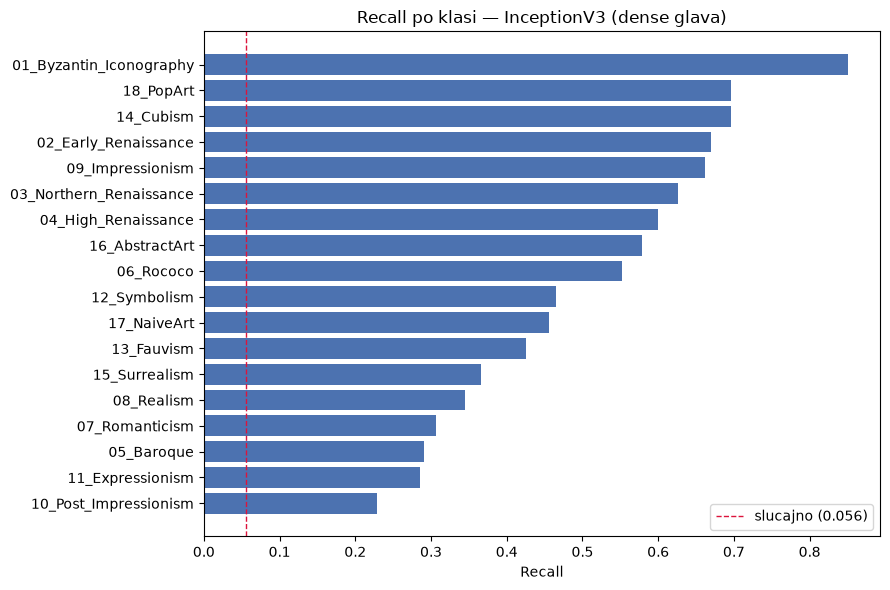

najlakse: 01_Byzantin_Iconography, 18_PopArt, 14_Cubism
najteze : 05_Baroque, 11_Expressionism, 10_Post_Impressionism


In [3]:
fig, ax = plt.subplots(figsize=(9, 6))
order = per_class.sort_values("recall")
ax.barh(order["klasa"], order["recall"], color="#4C72B0")
ax.axvline(1 / len(names), color="crimson", linestyle="--", linewidth=1,
           label=f"slucajno ({1/len(names):.3f})")
ax.set_xlabel("Recall")
ax.set_title("Recall po klasi — InceptionV3 (dense glava)")
ax.legend()
fig.tight_layout()
FIG.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG / "transfer_dense_recall_per_class.png", dpi=150)
plt.show()

print("najlakse:", ", ".join(per_class.head(3)["klasa"]))
print("najteze :", ", ".join(per_class.tail(3)["klasa"]))

## 2. Najčešće zamene

Najveće vrednosti van dijagonale matrice konfuzije — parovi koje model meša.

In [4]:
cm = np.loadtxt(EXP / "confusion_matrix.csv", delimiter=",", dtype=int)

pairs = [
    {"tacna": names[i], "predvidjena": names[j], "slika": int(cm[i, j]),
     "udeo u klasi": cm[i, j] / cm[i].sum()}
    for i in range(len(names)) for j in range(len(names)) if i != j and cm[i, j] > 0
]
top_confusions = (
    pd.DataFrame(pairs).sort_values("slika", ascending=False).head(10).reset_index(drop=True)
)
top_confusions

,tacna,predvidjena,slika,udeo u klasi
0,10_Post_Impressionism,09_Impressionism,53,0.276042
1,08_Realism,09_Impressionism,50,0.277778
2,05_Baroque,06_Rococo,36,0.243243
3,10_Post_Impressionism,13_Fauvism,27,0.140625
4,05_Baroque,04_High_Renaissance,26,0.175676
5,12_Symbolism,09_Impressionism,24,0.150943
6,16_AbstractArt,14_Cubism,23,0.144654
7,11_Expressionism,09_Impressionism,23,0.149351
8,07_Romanticism,06_Rococo,20,0.149254
9,15_Surrealism,14_Cubism,20,0.124224


**Za diskusiju:** da li se mešaju istorijski susedni pokreti (impresionizam ↔ postimpresionizam,
rana ↔ visoka renesansa)? Takve greške su očekivane i za čoveka sporne, za razliku od zamena
između udaljenih pokreta, koje ukazuju na slabost modela.

## 3. Konkretni promašaji

Predikcije se računaju iz **keširanih feature-a** (`features/test.npz`) propuštenih kroz
sačuvanu glavu — ne treba ponovo prolaziti slike kroz celu mrežu.

In [5]:
from tensorflow import keras

data = np.load(EXP / "features" / "test.npz")
X_test, y_true = data["X"], data["y"]

head = keras.models.load_model(EXP / "head_best.keras")
probs = head.predict(X_test, verbose=0)
y_pred = probs.argmax(axis=1)
confidence = probs.max(axis=1)

print("test accuracy (provera):", round(float((y_pred == y_true).mean()), 4))

I0000 00:00:1788086263.033931  809140 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1766 MB memory:  -> device: 0, name: NVIDIA RTX A500 Laptop GPU, pci bus id: 0000:03:00.0, compute capability: 8.6


test accuracy (provera): 0.4993


In [6]:
_, _, test_df = load_splits()
assert len(test_df) == len(y_true), "test.csv i kes nisu iste duzine"

def autor_i_delo(path):
    """Izvlaci autora i naziv dela iz putanje Pandora_18k/<klasa>/<Autor>/<naziv>.jpg.

    Skup imenuje foldere nedosledno ("Rosseau Henry", "andre-derain", "Artists"),
    a nazivi dela ponekad ponavljaju ime autora ili su samo redni broj.
    """
    autor = Path(path).parent.name.replace("_", " ").replace("-", " ").strip()
    if autor.islower():
        autor = autor.title()

    delo = Path(path).stem.replace("_", " ").replace("-", " ").strip()

    # skloni ime autora sa pocetka naziva dela, da se ne ponavlja u naslovu
    reci = autor.lower().split()
    tokeni = delo.split()
    while tokeni and tokeni[0].lower() in reci:
        tokeni.pop(0)
    delo = " ".join(tokeni).strip()

    if not delo or delo.isdigit():
        delo = "(bez naziva)"
    return autor, delo


meta = [autor_i_delo(f) for f in test_df["filepath"]]

errors = pd.DataFrame({
    "filepath": test_df["filepath"],
    "autor": [a for a, _ in meta],
    "delo": [d for _, d in meta],
    "tacna": [names[i] for i in y_true],
    "predvidjena": [names[i] for i in y_pred],
    "sigurnost": confidence,
})
errors = errors[errors["tacna"] != errors["predvidjena"]]

print(f"pogresnih: {len(errors)} od {len(y_true)}")
# najsigurnije greske su najzanimljivije - model je ubedjen a promasio je
errors.sort_values("sigurnost", ascending=False).head(10)[
    ["autor", "delo", "tacna", "predvidjena", "sigurnost"]
].reset_index(drop=True)

pogresnih: 1355 od 2706


,autor,delo,tacna,predvidjena,sigurnost
0,Klee Paul,senecio 19221,14_Cubism,16_AbstractArt,0.988043
1,Edward Burne Jones,the mirror of venus,12_Symbolism,02_Early_Renaissance,0.976419
2,Valtat Louis,xx Woman with Grapes 1900 xx Private collection,13_Fauvism,09_Impressionism,0.969549
3,Anonym unidentified,(bez naziva),05_Baroque,06_Rococo,0.968274
4,Klee Paul,view towards the port of hammamet 1914,14_Cubism,16_AbstractArt,0.965925
5,Clarence Holbrook Carter,joseph and his brothers 1971,16_AbstractArt,18_PopArt,0.962804
6,Ekster Aleksandra,color dynamics 1914,16_AbstractArt,14_Cubism,0.959552
7,Jozsef Rippl Ronai,cherry tree blossoms,12_Symbolism,09_Impressionism,0.956531
8,Klee Paul,oriental garden 19391,14_Cubism,16_AbstractArt,0.953267
9,Jim Dine,tool box 6 1966,18_PopArt,14_Cubism,0.951822


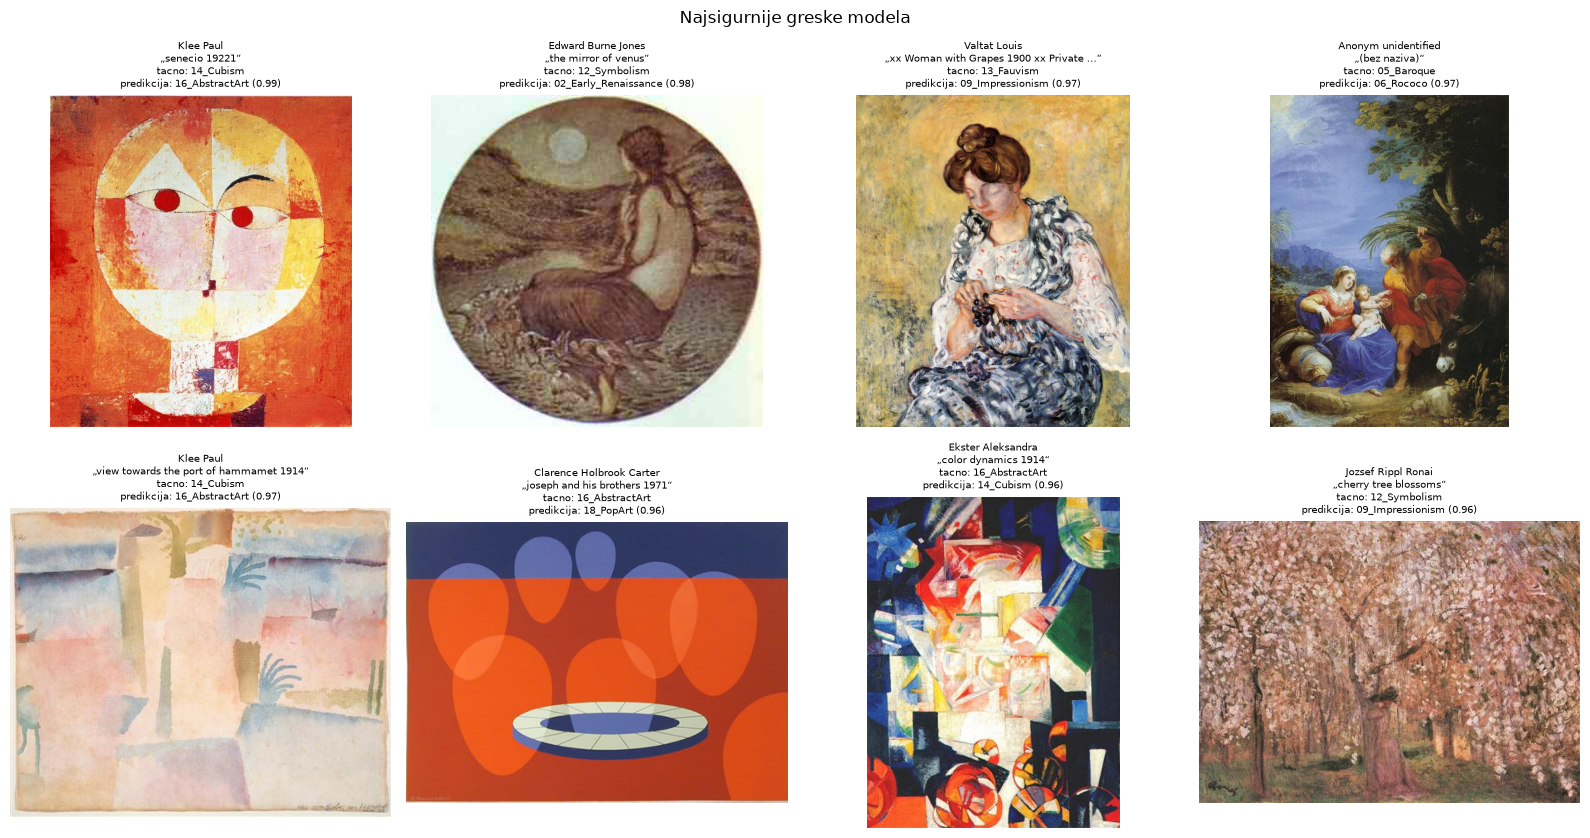

In [7]:
from PIL import Image

uzorak = errors.sort_values("sigurnost", ascending=False).head(8)

def skrati(tekst, n=38):
    return tekst if len(tekst) <= n else tekst[: n - 1] + "\u2026"

fig, axes = plt.subplots(2, 4, figsize=(16, 8.5))
for ax, (_, row) in zip(axes.ravel(), uzorak.iterrows()):
    ax.imshow(Image.open(row["filepath"]).convert("RGB"))
    ax.set_title(
        f"{skrati(row['autor'], 28)}\n"
        f"\u201e{skrati(row['delo'])}\u201c\n"
        f"tacno: {row['tacna']}\n"
        f"predikcija: {row['predvidjena']} ({row['sigurnost']:.2f})",
        fontsize=7.5,
    )
    ax.axis("off")

fig.suptitle("Najsigurnije greske modela")
fig.tight_layout()
fig.savefig(FIG / "transfer_dense_errors.png", dpi=150)
plt.show()

## 4. Zaključak

- **Lake klase.** Vizantijska ikonografija (recall 0.85), pop art i kubizam (0.70) - pokreti sa
  najizrazitijim vizuelnim potpisom.

- **Teške klase.** Postimpresionizam (0.23), ekspresionizam i barok (0.29). Sve česte zamene su
  između istorijski susednih pokreta (postimpresionizam / impresionizam, 53 slike), pa su greške
  uglavnom razumljive.

- **Šta bi pomoglo.** Train ~51% naspram val ~52% znači da model podbacuje, ne preprilagođava se -
  sledeći korak je fine-tuning.